In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
import warnings
warnings.filterwarnings("ignore")

In [33]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [34]:
train.head(3)

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed


In [35]:
print(train.shape)

(45000, 15)


In [36]:
test.head(3)

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,15202,23,Male,B.Tech,Civil,7.32,2,4,5,6,56,6,1,0,Placed
1,4573,24,Female,MCA,ME,4.76,0,1,1,4,37,4,0,3,Not Placed
2,34424,20,Male,BCA,ME,6.16,0,3,3,8,68,6,1,3,Not Placed


In [37]:
print(test.shape)

(5000, 15)


In [38]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            45000 non-null  int64  
 1   Age                   45000 non-null  int64  
 2   Gender                45000 non-null  object 
 3   Degree                45000 non-null  object 
 4   Branch                45000 non-null  object 
 5   CGPA                  45000 non-null  float64
 6   Internships           45000 non-null  int64  
 7   Projects              45000 non-null  int64  
 8   Coding_Skills         45000 non-null  int64  
 9   Communication_Skills  45000 non-null  int64  
 10  Aptitude_Test_Score   45000 non-null  int64  
 11  Soft_Skills_Rating    45000 non-null  int64  
 12  Certifications        45000 non-null  int64  
 13  Backlogs              45000 non-null  int64  
 14  Placement_Status      45000 non-null  object 
dtypes: float64(1), int6

In [39]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            5000 non-null   int64  
 1   Age                   5000 non-null   int64  
 2   Gender                5000 non-null   object 
 3   Degree                5000 non-null   object 
 4   Branch                5000 non-null   object 
 5   CGPA                  5000 non-null   float64
 6   Internships           5000 non-null   int64  
 7   Projects              5000 non-null   int64  
 8   Coding_Skills         5000 non-null   int64  
 9   Communication_Skills  5000 non-null   int64  
 10  Aptitude_Test_Score   5000 non-null   int64  
 11  Soft_Skills_Rating    5000 non-null   int64  
 12  Certifications        5000 non-null   int64  
 13  Backlogs              5000 non-null   int64  
 14  Placement_Status      5000 non-null   object 
dtypes: float64(1), int64(

In [40]:
train.describe()

,Student_ID,Age,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,24977.962600,20.999333,7.002290,0.774089,3.734222,5.691800,5.501644,69.385356,5.501644,1.800956,0.888133
std,14425.605704,1.995071,0.993855,0.844750,0.923738,1.994674,1.515374,13.909710,1.238722,0.650104,0.970954
min,1.000000,18.000000,4.500000,0.000000,1.000000,1.000000,1.000000,35.000000,1.000000,0.000000,0.000000
25%,12509.750000,19.000000,6.320000,0.000000,3.000000,4.000000,4.000000,60.000000,5.000000,1.000000,0.000000
50%,24957.500000,21.000000,7.000000,1.000000,4.000000,6.000000,6.000000,69.000000,5.000000,2.000000,1.000000
75%,37475.250000,23.000000,7.670000,1.000000,4.000000,7.000000,7.000000,79.000000,6.000000,2.000000,2.000000
max,50000.000000,24.000000,9.800000,3.000000,6.000000,10.000000,10.000000,100.000000,10.000000,3.000000,3.000000


In [41]:
test.describe()

,Student_ID,Age,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,25203.336600,21.006000,7.005410,0.770600,3.748800,5.720800,5.483800,69.523000,5.509800,1.807200,0.869800
std,14508.219611,1.994883,1.000486,0.852362,0.919928,1.987369,1.524796,13.879481,1.243307,0.648161,0.959704
min,12.000000,18.000000,4.500000,0.000000,1.000000,1.000000,1.000000,35.000000,1.000000,0.000000,0.000000
25%,12423.500000,19.000000,6.330000,0.000000,3.000000,4.000000,4.000000,60.000000,5.000000,1.000000,0.000000
50%,25468.500000,21.000000,7.010000,1.000000,4.000000,6.000000,5.000000,70.000000,6.000000,2.000000,1.000000
75%,37718.250000,23.000000,7.690000,1.000000,4.000000,7.000000,7.000000,79.000000,6.000000,2.000000,2.000000
max,49999.000000,24.000000,9.800000,3.000000,6.000000,10.000000,10.000000,100.000000,10.000000,3.000000,3.000000


In [42]:
test.isnull().sum()

Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64

In [43]:
train.isnull().sum()

Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64

In [44]:
test.columns

Index(['Student_ID', 'Age', 'Gender', 'Degree', 'Branch', 'CGPA',
       'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills',
       'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications',
       'Backlogs', 'Placement_Status'],
      dtype='object')

In [45]:
test_df = test[['CGPA','Internships', 'Projects', 'Coding_Skills', 'Communication_Skills',
                'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications','Backlogs',]]
test_df.corr()

,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs
CGPA,1.000000,0.373515,0.700338,0.467587,-0.011338,0.701820,-0.035854,0.547589,-0.584271
Internships,0.373515,1.000000,0.522192,0.537636,-0.007554,0.273367,-0.023267,0.477901,-0.220172
Projects,0.700338,0.522192,1.000000,0.894409,0.001947,0.500845,-0.026705,0.827603,-0.416125
Coding_Skills,0.467587,0.537636,0.894409,1.000000,0.004976,0.337021,-0.022127,0.858133,-0.289973
Communication_Skills,-0.011338,-0.007554,0.001947,0.004976,1.000000,-0.008423,0.005993,-0.001137,-0.003014
Aptitude_Test_Score,0.701820,0.273367,0.500845,0.337021,-0.008423,1.000000,-0.027359,0.528737,-0.409168
Soft_Skills_Rating,-0.035854,-0.023267,-0.026705,-0.022127,0.005993,-0.027359,1.000000,-0.024712,0.005512
Certifications,0.547589,0.477901,0.827603,0.858133,-0.001137,0.528737,-0.024712,1.000000,-0.328504
Backlogs,-0.584271,-0.220172,-0.416125,-0.289973,-0.003014,-0.409168,0.005512,-0.328504,1.000000


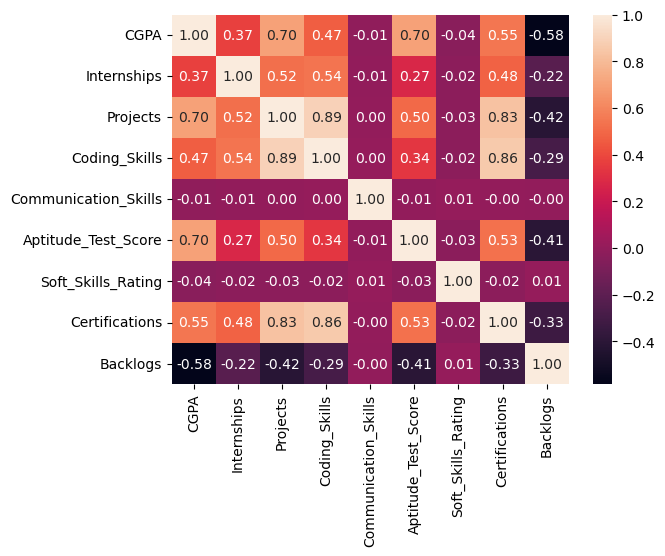

In [46]:
sns.heatmap(test_df.corr(), cbar = True, annot = True, fmt = '0.2f')
plt.show()

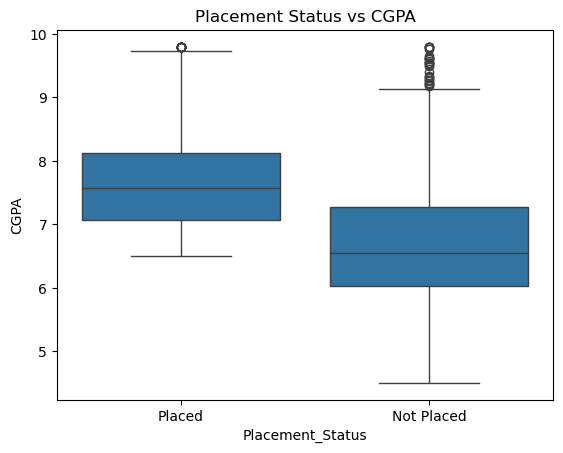

In [47]:
sns.boxplot(x='Placement_Status', y='CGPA', data = test)
plt.title("Placement Status vs CGPA")
plt.show()

In [48]:
test.groupby("Placement_Status")[['CGPA','Internships', 'Projects', 'Coding_Skills', 'Communication_Skills',
                'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications','Backlogs']].mean()

,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs
Placement_Status,,,,,,,,,
Not Placed,6.642403,0.575596,3.402760,5.060226,5.104454,65.458908,5.516625,1.577792,1.226161
Placed,7.644078,1.113687,4.357616,6.883002,6.151214,76.673289,5.497792,2.210817,0.242826


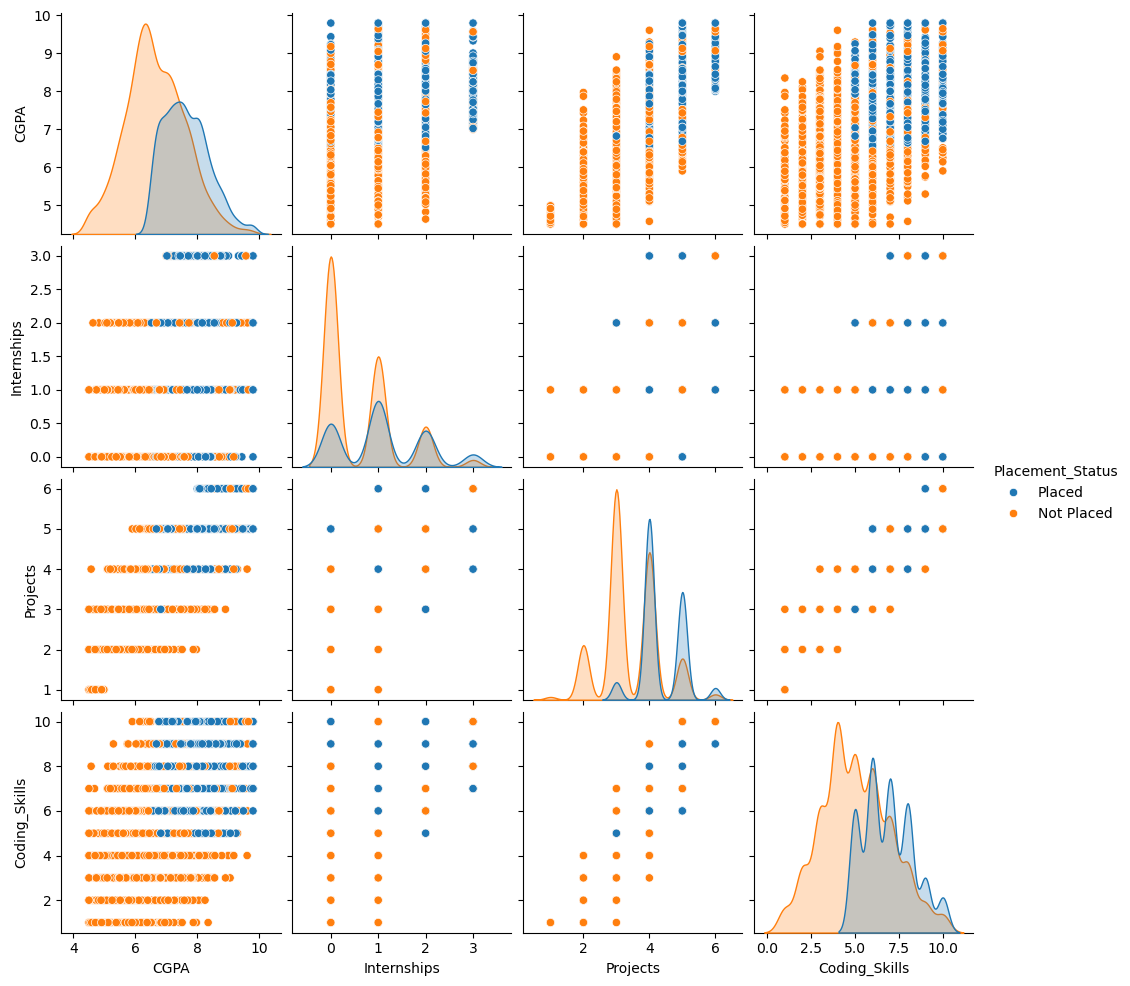

In [49]:
sns.pairplot(
    data = test,
    vars = ['CGPA','Internships', 'Projects', 'Coding_Skills'],
    hue = "Placement_Status"
)

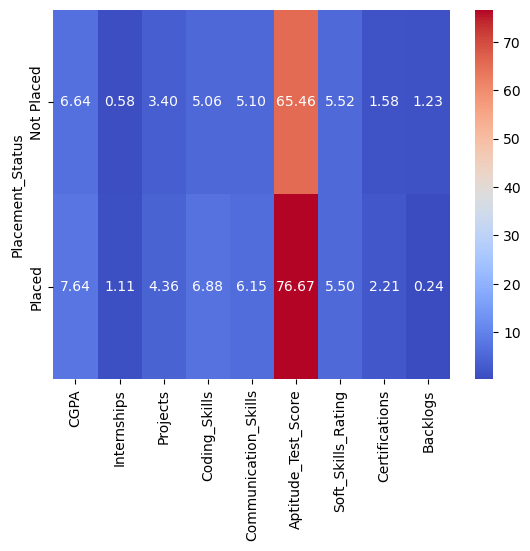

In [50]:
sns.heatmap(test.groupby("Placement_Status")[['CGPA','Internships', 'Projects', 'Coding_Skills', 'Communication_Skills',
                'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications','Backlogs']].mean(),
            annot = True, 
            fmt = "0.2f",
            cbar = True,
            cmap = "coolwarm"      
    )

plt.show()

### **Support Vector Machine (SVM)**

In [51]:
cols = ['CGPA','Internships','Projects','Coding_Skills',
        'Communication_Skills','Aptitude_Test_Score',
        'Soft_Skills_Rating','Certifications','Backlogs']

scaler = StandardScaler()

scaled_df = test.copy()
scaled_df[cols] = scaler.fit_transform(test[cols])

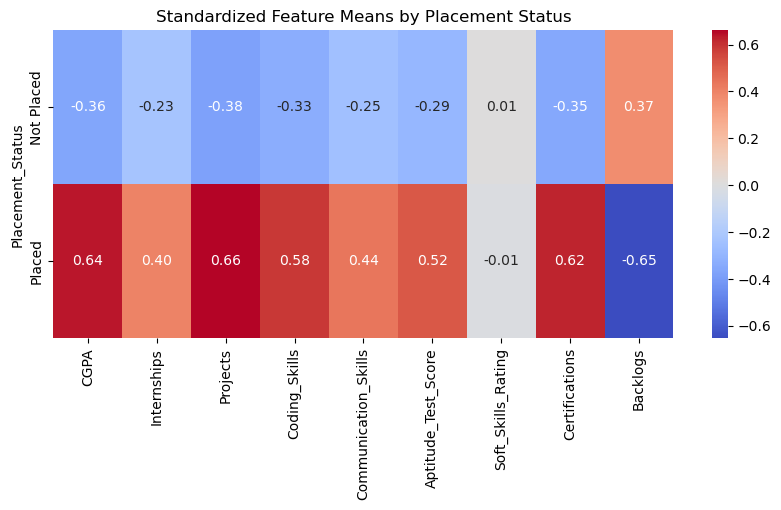

In [52]:
plt.figure(figsize=(10,4))

sns.heatmap(
    scaled_df.groupby("Placement_Status")[cols].mean(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Standardized Feature Means by Placement Status")
plt.show()

In [53]:
x_train = train.drop(["Placement_Status", "Student_ID"], axis = 1)
y_train = train["Placement_Status"]

x_test = test.drop(["Placement_Status", "Student_ID"], axis = 1)
y_test = test["Placement_Status"]

In [54]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(45000, 13)
(45000,)
(5000, 13)
(5000,)


In [55]:
## One Hot Encoding
x_train = pd.get_dummies(
    x_train,
    columns = ['Gender', 'Degree', 'Branch'],
    drop_first = True
)

x_test = pd.get_dummies(
    x_test,
    columns = ['Gender', 'Degree', 'Branch'],
    drop_first = True
)

In [56]:
print(x_train.columns.tolist())

['Age', 'CGPA', 'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications', 'Backlogs', 'Gender_Male', 'Degree_B.Tech', 'Degree_BCA', 'Degree_MCA', 'Branch_Civil', 'Branch_ECE', 'Branch_IT', 'Branch_ME']


In [58]:
svm_model = SVC(random_state = 42)
svm_model.fit(x_train, y_train)

SVC(random_state=42)

In [60]:
y_pred = svm_model.predict(x_test)

In [66]:
print(y_pred)

['Not Placed' 'Not Placed' 'Not Placed' ... 'Not Placed' 'Placed'
 'Not Placed']


In [67]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred, pos_label = "Placed"))
print("Recall   :", recall_score(y_test, y_pred, pos_label='Placed'))
print("F1 Score :", f1_score(y_test, y_pred, pos_label='Placed'))

Accuracy:  0.8794
Precision:  0.8326912493120529
Recall   : 0.8349889624724062
F1 Score : 0.8338385230090934


In [69]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[2884,  304],
       [ 299, 1513]])

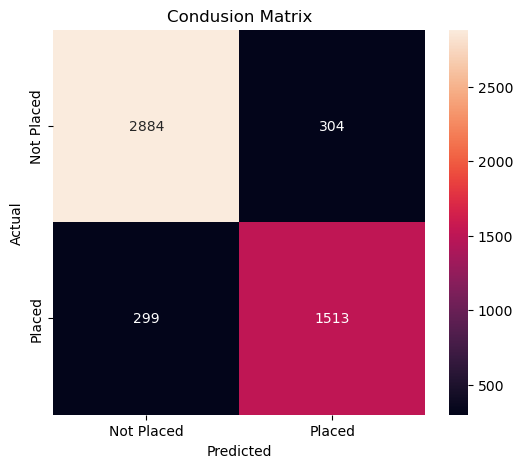

In [70]:
plt.figure(figsize = (6, 5))

sns.heatmap(
    cm, 
    annot = True, 
    fmt = 'd',
    xticklabels = ['Not Placed', 'Placed'],
    yticklabels = ['Not Placed', 'Placed'],
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Condusion Matrix")
plt.show()

In [72]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  Not Placed       0.91      0.90      0.91      3188
      Placed       0.83      0.83      0.83      1812

    accuracy                           0.88      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.88      0.88      0.88      5000



In [73]:
print(y_train.value_counts())

Placement_Status
Not Placed    28688
Placed        16312
Name: count, dtype: int64


In [74]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)
x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train)

print(y_train_balanced.value_counts()) 

Placement_Status
Not Placed    28688
Placed        28688
Name: count, dtype: int64


In [75]:
svm_model = SVC(random_state = 42)
svm_model.fit(x_train_balanced, y_train_balanced)

SVC(random_state=42)

In [76]:
y_pred = svm_model.predict(x_test)

In [77]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred, pos_label = "Placed"))
print("Recall: ", recall_score(y_test, y_pred, pos_label = "Placed"))
print("F1 Score: ", f1_score(y_test, y_pred, pos_label = "Placed"))

Accuracy:  0.8658
Precision:  0.7618173474070674
Recall:  0.9161147902869757
F1 Score:  0.8318717113505387


In [79]:
from sklearn.model_selection import GridSearchCV

In [85]:
param_grid = {
    'kernel': ['linear', 'rbf']
}

grid = GridSearchCV(
    estimator = SVC(),
    param_grid = param_grid,
    cv = 3,
    scoring = "accuracy",
    n_jobs = 1
)

grid.fit(x_train, y_train)

GridSearchCV(cv=3, estimator=SVC(), n_jobs=1,
             param_grid={'kernel': ['linear', 'rbf']}, scoring='accuracy')

In [86]:
print(grid.best_params_)
print(grid.best_score_)

{'kernel': 'rbf'}
0.871311111111111


In [87]:
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.8794


In [88]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="Placed"))
print("Recall   :", recall_score(y_test, y_pred, pos_label="Placed"))
print("F1 Score :", f1_score(y_test, y_pred, pos_label="Placed"))

print(classification_report(y_test, y_pred))

Accuracy : 0.8794
Precision: 0.8326912493120529
Recall   : 0.8349889624724062
F1 Score : 0.8338385230090934
              precision    recall  f1-score   support

  Not Placed       0.91      0.90      0.91      3188
      Placed       0.83      0.83      0.83      1812

    accuracy                           0.88      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.88      0.88      0.88      5000



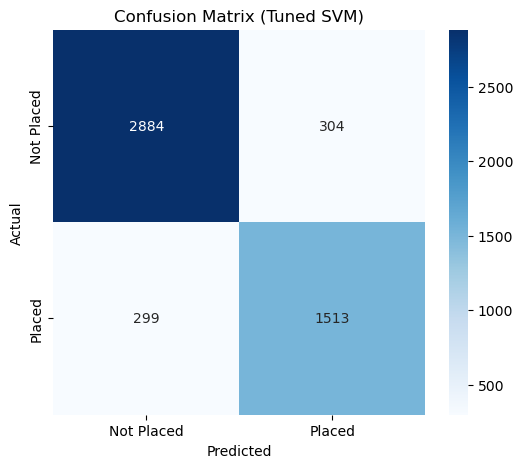

In [89]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Placed','Placed'],
    yticklabels=['Not Placed','Placed']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Tuned SVM)")
plt.show()

| Model                | Accuracy | Precision | Recall | F1 Score |
|----------------------|----------|-----------|--------|----------|
| Baseline SVM         | 87.94%   | 83.27%    | 83.50% | 83.38%   |
| SVM + SMOTE          | 86.58%   | 76.18%    | 91.61% | 83.19%   |
| Tuned SVM            | 87.94%   | 83.27%    | 83.50% | 83.38%   |